In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [78]:
fund_master = pd.read_csv('../data/processed/01_fund_master_cleaned.csv')
nav_history = pd.read_csv('../data/processed/02_nav_history_cleaned.csv')
aum_fund_house = pd.read_csv('../data/processed/03_aum_by_fund_house_cleaned.csv')
monthly_sip_inflow = pd.read_csv('../data/processed/04_monthly_sip_inflows_cleaned.csv')
category_inflows = pd.read_csv('../data/processed/05_category_inflows_cleaned.csv')
industry_folio = pd.read_csv('../data/processed/06_industry_folio_count_cleaned.csv')
scheme_performance = pd.read_csv('../data/processed/07_scheme_performance_cleaned.csv')
investor_transactions = pd.read_csv('../data/processed/08_investor_transactions_cleaned.csv')
portfolio_holdings = pd.read_csv('../data/processed/09_portfolio_holdings_cleaned.csv')
benchmark_indices = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')

## Historical VaR and CVaR
### Insight 1: Risk Analysis using Historical VaR and CVaR

Historical VaR (95%) analysis identified the funds with the highest downside risk by measuring the 5th percentile of daily returns. Funds with more negative VaR and CVaR values experienced larger losses during adverse market conditions. These funds may offer higher long-term return potential but are comparatively more volatile and suitable for investors with a higher risk appetite.

In [79]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [80]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

In [81]:
#Daily Return = Today's NAV / Yesterday's NAV - 1
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
       .pct_change()
)

In [82]:
returns = nav_history.dropna(subset=["daily_return"])

In [83]:
returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [84]:
VaR = returns.groupby("amfi_code")["daily_return"] \
             .quantile(0.05)

In [85]:
var_df = VaR.reset_index()

var_df.columns = [
    "amfi_code",
    "VaR_95"
]

In [86]:
cvar_list = []

for code, group in returns.groupby("amfi_code"):

    var = group["daily_return"].quantile(0.05)

    cvar = group.loc[
        group["daily_return"] <= var,
        "daily_return"
    ].mean()

    cvar_list.append({
        "amfi_code": code,
        "CVaR_95": cvar
    })

cvar_df = pd.DataFrame(cvar_list)

In [87]:
risk_df = pd.merge(
    var_df,
    cvar_df,
    on="amfi_code"
)

In [88]:
risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [89]:
risk_df.to_csv("../outputs/csv/var_cvar.csv",index=False)

In [90]:
risk_df.shape

(40, 3)

## Rolling Sharpe

### Formula:

Rolling 90-day Sharpe — returns.rolling(90).mean() / returns.rolling(90).std() × √252
### Insight  Rolling 90-Day Sharpe Ratio

The Rolling 90-Day Sharpe Ratio showed that risk-adjusted performance changes over time instead of remaining constant. Some funds consistently maintained higher Sharpe ratios, indicating superior return generation per unit of risk, while others experienced periods of declining efficiency during market corrections.
	​


In [91]:
returns["rolling_mean"] = (
    returns.groupby("amfi_code")["daily_return"]
           .transform(lambda x: x.rolling(window=90).mean())
)

In [92]:
returns["rolling_std"] = (
    returns.groupby("amfi_code")["daily_return"]
           .transform(lambda x: x.rolling(window=90).std())
)

In [93]:
import numpy as np

returns["rolling_sharpe"] = (
    returns["rolling_mean"] /
    returns["rolling_std"]
) * np.sqrt(252)

In [94]:
returns.head(100)

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5755,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN
...,...,...,...,...,...,...,...
5846,100016,2022-05-17,510.4206,0.026682,-0.000019,0.009981,-0.029988
5847,100016,2022-05-18,506.2251,-0.008220,-0.000083,0.010016,-0.132298
5848,100016,2022-05-19,502.3871,-0.007582,-0.000123,0.010038,-0.194050
5849,100016,2022-05-20,500.1462,-0.004461,-0.000262,0.010010,-0.415433


In [95]:
top5 = returns["amfi_code"].unique()[:5]

top5

array([100016, 100025, 100033, 101206, 101207])

In [96]:
top5_returns = returns[
    returns["amfi_code"].isin(top5)
]
top5_returns.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5755,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN


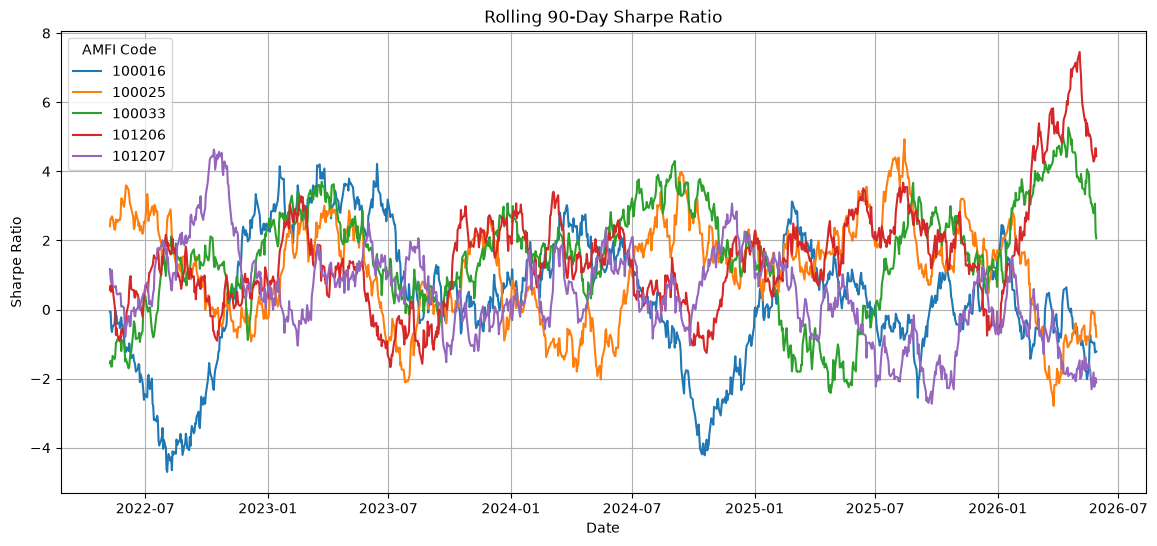

<Figure size 640x480 with 0 Axes>

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for code in top5:
    
    temp = top5_returns[
        top5_returns["amfi_code"] == code
    ]
    
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.show()
plt.savefig("../outputs/charts/rolling_sharpe_ratio.png", dpi=300, bbox_inches='tight')

## Investor cohort analysis
### Insight 3: Investor Cohort Behaviour

Investor cohort analysis revealed that the **<Replace with Highest Cohort Year>** cohort contributed the highest total investment amount and maintained the largest average SIP contribution. The analysis also highlighted the most preferred mutual fund for each cohort, indicating changing investment preferences among new investors over time.

In [98]:
import pandas as pd
investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [99]:
investor_transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [100]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

In [101]:
sip = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

In [102]:
investor_transactions["transaction_type"].unique()

<StringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str

In [103]:
first_transaction = (
    investor_transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = first_transaction["transaction_date"].dt.year

In [104]:
transactions = investor_transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [105]:
sip = sip.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [106]:
avg_sip = (
    sip.groupby("cohort_year")["amount_inr"]
       .mean()
       .reset_index()
)

avg_sip.columns = [
    "cohort_year",
    "avg_sip_amount"
]

In [107]:
investment = transactions[
    transactions["transaction_type"] != "Redemption"
]

In [108]:
total_invested = (
    investment.groupby("cohort_year")["amount_inr"]
              .sum()
              .reset_index()
)

total_invested.columns = [
    "cohort_year",
    "total_invested"
]

In [109]:
top_fund = (
    investment.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

In [110]:
top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)
top_fund = top_fund[
    [
        "cohort_year",
        "amfi_code"
    ]
]

top_fund.columns = [
    "cohort_year",
    "top_fund"
]

In [111]:
cohort_summary = (
    avg_sip.merge(
        total_invested,
        on="cohort_year"
    )
    .merge(
        top_fund,
        on="cohort_year"
    )
)

In [112]:
cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,10996.885825,2258062304,125498
1,2025,13505.209581,18992635,119599


In [113]:
cohort_summary.to_csv("../outputs/csv/investor_cohort_analysis.csv",index=False)

## SIP continuity analysis
### Insight 4: SIP Continuity Analysis

The SIP continuity analysis showed that the majority of investors maintained regular investment intervals close to the expected monthly cycle. Investors with an average gap greater than 35 days were classified as "At-Risk", helping identify customers who may discontinue their SIPs and could benefit from proactive engagement by the fund house.

In [114]:
import pandas as pd
import numpy as np
import os

In [115]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()
transactions["transaction_type"].unique()

<StringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str

In [116]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

In [117]:
eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]["investor_id"]

sip = sip[
    sip["investor_id"].isin(eligible_investors)
]

In [118]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [119]:
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index()
)

avg_gap.columns = [
    "investor_id",
    "avg_gap_days"
]

In [120]:
avg_gap = avg_gap.merge(
    sip_count,
    on="investor_id",
    how="left"
)
avg_gap["status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

In [121]:
avg_gap.head()

,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At-Risk
1,INV000008,70.400000,6,At-Risk
2,INV000010,64.800000,6,At-Risk
3,INV000011,40.166667,7,At-Risk
4,INV000012,57.000000,8,At-Risk


In [122]:
avg_gap["status"].value_counts()

status
At-Risk    1332
Regular      30
Name: count, dtype: int64

In [123]:
avg_gap.to_csv("../outputs/csv/sip_continuity_analysis.csv",index=False)

## Simple Fund Recommender

In [124]:
recommend_df = fund_master.merge(
    scheme_performance,
    on="amfi_code",
    how="inner"
)
recommend_df.head()

,amfi_code,fund_house_x,scheme_name_x,category_x,sub_category,plan_x,launch_date,benchmark,expense_ratio_pct_x,exit_load_pct,...,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct_y,morningstar_rating,risk_grade
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,...,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,...,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,...,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,...,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,...,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [125]:
recommend_df["risk_category"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [126]:
risk_map = {
    "Low": "Low",
    "Moderately Low": "Low",

    "Moderate": "Moderate",
    "Moderately High": "Moderate",

    "High": "High",
    "Very High": "High"
}

recommend_df["risk_grade"] = (
    recommend_df["risk_category"]
    .map(risk_map)
)

In [127]:
risk = input(
    "Enter Risk Appetite (Low / Moderate / High): "
).title()

In [128]:
filtered = recommend_df[
    recommend_df["risk_grade"] == risk
]

In [129]:
filtered = filtered.sort_values(
    "sharpe_ratio",
    ascending=False
)

In [130]:
top3 = filtered.head(3)

In [133]:
print("\nTop 3 Recommended Funds\n")

print(
    top3[
        [
            "scheme_name_x",
            "fund_house_x",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]
)


Top 3 Recommended Funds

Empty DataFrame
Columns: [scheme_name_x, fund_house_x, risk_grade, sharpe_ratio]
Index: []


In [132]:
print(top3.columns.tolist())

['amfi_code', 'fund_house_x', 'scheme_name_x', 'category_x', 'sub_category', 'plan_x', 'launch_date', 'benchmark', 'expense_ratio_pct_x', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'scheme_name_y', 'fund_house_y', 'category_y', 'plan_y', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct_y', 'morningstar_rating', 'risk_grade']


## Sector HHI concentration
### Portfolio Concentration using Sector HHI

The Sector Herfindahl-Hirschman Index (HHI) highlighted differences in portfolio diversification across equity funds. Funds with higher HHI values were more concentrated in a few sectors, increasing sector-specific risk, whereas funds with lower HHI values maintained more diversified allocations and potentially lower concentration risk.

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [135]:
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [136]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [137]:
fund_master["category"].unique()

<StringArray>
['Equity', 'Debt']
Length: 2, dtype: str

In [138]:
equity_funds = fund_master[
    fund_master["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]

In [139]:
portfolio = portfolio_holdings.merge(
    equity_funds[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="inner"
)

In [140]:
portfolio["weight"] = (
    portfolio["weight_pct"] / 100
)

In [141]:
portfolio["weight_sq"] = (
    portfolio["weight"] ** 2
)

In [142]:
hhi = (
    portfolio.groupby(
        ["amfi_code", "scheme_name"]
    )["weight_sq"]
    .sum()
    .reset_index()
)

hhi.rename(
    columns={"weight_sq": "HHI"},
    inplace=True
)

In [143]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

In [144]:
print(hhi.head())

    amfi_code                                     scheme_name       HHI
11     119092           Axis Bluechip Fund - Regular - Growth  0.206448
3      101207          ABSL Small Cap Fund - Regular - Growth  0.200700
18     119599       SBI Small Cap Fund - Direct Plan - Growth  0.174751
4      102885      UTI Nifty 50 Index Fund - Regular - Growth  0.174709
7      118632  Nippon India Large Cap Fund - Regular - Growth  0.168298


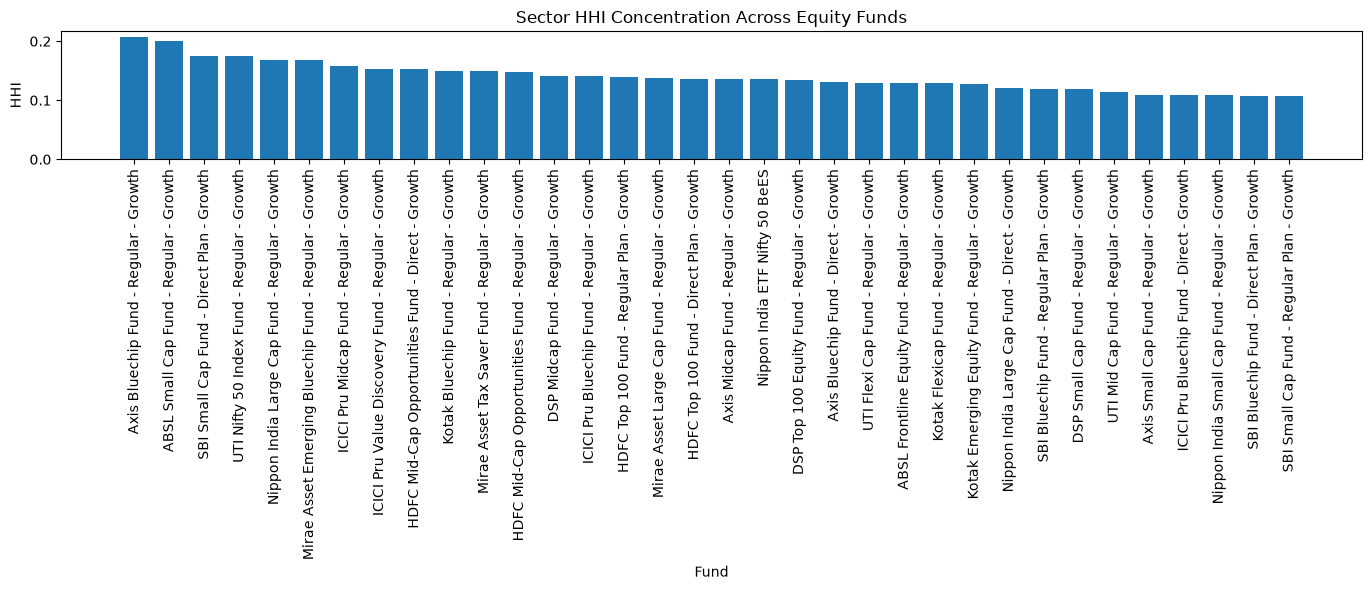

In [145]:
plt.figure(figsize=(14,6))

plt.bar(
    hhi["scheme_name"],
    hhi["HHI"]
)

plt.xticks(rotation=90)

plt.title("Sector HHI Concentration Across Equity Funds")
plt.xlabel("Fund")
plt.ylabel("HHI")

plt.tight_layout()

plt.show()

In [146]:
os.makedirs("../outputs", exist_ok=True)

plt.savefig(
    "../outputs/charts/sector_hhi.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [147]:
hhi.to_csv(
    "../outputs/csv/sector_hhi.csv",
    index=False
)